# 07 — Final (living): Caller-Level Volume on the **canonical table**

**This is the working notebook for the re-analysis.** It begins as a faithful re-run of
`06_caller_level_volume_brizan_revisions_plus.ipynb`, changing exactly one thing: it reads the
**single canonical feature table** (`utterances_v2/derived/features_table.csv`) through the
guarded loader `swb_extract.analysis.load_features_table`, instead of the frozen 03-era
`paper_aligned_standardized_PCA.csv` that 06 read. From here we keep adding to and adjusting
this notebook as we work through the audit's concerns (`docs/AUDIT.md`); 06's recorded numbers
are inherited only until re-confirmed by this run's own outputs (see the reconciled conclusion).

**Why the canonical table (`docs/PIPELINE.md`).** There is exactly one derived table; every
trustworthy notebook loads it through one function and nothing else. Two guards run on every
load — a **stale-data guard** (raises if any `features/*.csv` / `manifest.csv` is newer than the
built table, telling you to `swb-extract table`) and a **registry guard** (raises on any column
not registered in `docs/FEATURES.md`) — so this notebook *cannot* silently run on out-of-date or
unvetted features. `include="provisional"` takes validated + WIP columns (the experimentation
default; the loader prints the WIP columns it hands us). This is the integration PIPELINE.md
calls the "trustworthy line (notebook 06 onward)": 06 *described* it but still read the frozen
CSV, so 07 is where it is actually wired up.

**Feature set (04's block, one corrected feature):** the paper-aligned volume block —
Table 1's 14 features minus the 3 pitch features = 11 (`token_count`, loudness
mean/std/range, **`FTO Sec`**, `word_rate`, `syllable_rate`, `Pronouns per Second`,
repetitions current/previous, `Filler Words per Second`). The paper's `Turn Gap` is
replaced by **floor-transfer offset (FTO)** — the corrected response-timing feature
(AUDIT.md §3.1; Heldner & Edlund 2010), restricted to the [-2, +2] s turn-taking window.
Other interactional features (latching, overlap, questions, ...) are a separate WIP and are
**not** used here.

**Pseudoreplication fixed (unchanged from 04):** "speaker" = the **caller**, not the
`sw####A/B` conversation side. Each caller appears across ~9 calls; grouping by side
inflates n ~9x. We map side -> `caller_no` via `tables/call_con_tab.csv`.

**What changed vs 04:**
1. **`Turn Gap` -> FTO (the one feature change).** `Turn Gap` measured `current.start -
   previous.end` against the chronological predecessor *including the listener's
   backchannels*, so 60% of values were negative and the median "gap" was -0.49 s — broken.
   It is replaced by **floor-transfer offset**: merge same-speaker runs into turns, exclude
   backchannel/interjection predecessors, and time the gap only at genuine floor transfers,
   restricted to a [-2, +2] s response window (AUDIT.md §3.1). A **Step 1b** validates its
   distribution against the turn-taking literature (~+200 ms with an overlap tail).
2. **PC naming -> 1-indexed** (`PC1, PC2, ...`). The old `PC0` was a 0-indexing artifact.
3. **Dropped silhouette** (and the forced-k=2 split). Silhouette only scores how cleanly
   you can *force* a partition — uninformative for a continuum.
4. **Added distribution-shape battery:** skew, **excess kurtosis**, and **Hartigan's
   dip test** (formal unimodality test) on every retained PC. Kept a single GMM
   BIC(k=1 vs k=2) line as direct corroboration of the old "BIC picked k=2" worry.
5. **Added Horn's parallel analysis** to choose how many PCs to retain (PC1 explains
   only ~40%, so more than one component carries signal).
6. **Demographics reported as mean +/- SD +/- n over callers**, with significance tests
   (Welch t for gender; one-way ANOVA for region/generation/education) and
   **Benjamini-Hochberg FDR** across the family; plus a **group-overlay figure**
   (per-group density curves on the pooled histogram) for the paper.

**What changed vs 06:** only the data source — the frozen `paper_aligned_standardized_PCA.csv`
-> the live canonical table via `load_features_table(include="provisional")`. The canonical
table carries ~2k more utterances (214,204 vs 212,211) and the current extractor outputs, and
already contains `FTO Sec`, so 06's separate `fto.csv` merge is dropped. The analysis (caller
roll-up, own StandardScaler + PCA, parallel analysis, dip/shape battery, FDR demographics) is
unchanged — note 06 never used the file's precomputed `pca_*`/`gmm_*` columns, it recomputes
its own, so nothing is lost by the canonical table not having them. Headline numbers are
re-derived below on the larger, fresher data.

In [1]:
import pandas as pd, numpy as np, string
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from scipy.stats import skew, kurtosis, gaussian_kde, ttest_ind, f_oneway, norm
from scipy.signal import find_peaks
from diptest import diptest
import seaborn as sns, matplotlib.pyplot as plt
from swb_extract.analysis import load_features_table  # single guarded entry to the canonical table

# Benjamini-Hochberg FDR-adjusted p-values (avoids a statsmodels dependency)
def bh_fdr(pvals):
    p = np.asarray(pvals, dtype=float)
    m = len(p)
    order = np.argsort(p)
    adj = np.empty(m)
    prev = 1.0
    for rank in range(m - 1, -1, -1):
        idx = order[rank]
        prev = min(prev, p[idx] * m / (rank + 1))
        adj[idx] = prev
    return adj

## Step 1 — Load utterances & roll up conversation sides to callers (pseudoreplication fix)

In [2]:
# --- Canonical feature table (AUDIT.md §3 fix 2; docs/PIPELINE.md) ---------------------
# Load the ONE canonical per-utterance table (utterances_v2/derived/features_table.csv)
# through the single guarded entry point, replacing 06's frozen 03-era
# `paper_aligned_standardized_PCA.csv`. include="provisional" = validated + WIP columns
# (experimentation default); the loader runs its stale-data + registry guards on every
# call, so this notebook cannot silently run on out-of-date or unregistered features.
df = load_features_table(include="provisional")

# --- Floor-Transfer Offset (FTO) replaces the broken `Turn Gap` (AUDIT.md §3.1) --------
# `Turn Gap` = current.start - previous.end against the chronological predecessor
# INCLUDING the listener's backchannels, so 60% of its values were negative (median
# -0.49 s) — segmentation arithmetic, not response timing. FTO (Heldner & Edlund 2010)
# merges same-speaker runs into turns, excludes backchannel/interjection predecessors,
# and times the gap only at genuine floor transfers. It now ships IN the canonical table
# (src/swb_extract/features/fto.py, unit-tested in tests/test_fto.py), so 06's separate
# fto.csv merge is gone. Keep the raw pre-window values for the Step 1b external-validity
# check before masking to the response window.
_fto = df[["Utterance File Name", "FTO Sec"]].copy()   # raw floor transfers (pre-window)

# Restrict to the turn-taking RESPONSE window before aggregating. A silence beyond ~1-2 s
# is a lapse, not a response (Stivers et al. 2009; Levinson & Torreira 2015), and the raw
# tail runs to +68 s / -10 s (dropped-utterance gaps). Mask anything outside [-2, +2] s to
# NaN so each caller's mean is taken over genuine, in-window floor transfers only.
FTO_LO, FTO_HI = -2.0, 2.0
_n_transfer = int(df["FTO Sec"].notna().sum())
df.loc[(df["FTO Sec"] < FTO_LO) | (df["FTO Sec"] > FTO_HI), "FTO Sec"] = np.nan
_n_kept = int(df["FTO Sec"].notna().sum())
print(f"FTO floor transfers: {_n_transfer} | kept in [{FTO_LO}, {FTO_HI}] s: {_n_kept} "
      f"({100*_n_kept/_n_transfer:.1f}%) | dropped lapses/deep-overlaps: {_n_transfer - _n_kept}")

# --- speaker roll-up: collapse conversation SIDES to the actual CALLER ----------
# "sw####A/B" is a conversation SIDE, not a person. Each caller takes part in ~9
# calls, so grouping by side pseudo-replicates every speaker ~9x and inflates n in
# every downstream test (PCA point count, BIC, the gender Welch t).
# Map (conversation_no, side) -> caller_no with the corpus table and use the
# caller as the speaker, pooling all of their utterances across calls.
df["side"] = df["Utterance File Name"].str.extract(r"(sw\d+[AB])")
_cc = pd.read_csv("../tables/call_con_tab.csv", header=None,
                  names=["conv", "conv_side", "caller", "phone", "length",
                         "ivi", "remarks", "active"])
_cc["conv_side"] = _cc["conv_side"].str.strip().str.strip('"')
_side2caller = {f"sw{int(c):04d}{s}": int(k)
                for c, s, k in zip(_cc["conv"], _cc["conv_side"], _cc["caller"])}
df["speaker"] = df["side"].map(_side2caller)   # speaker == caller_no (the person)
_unmapped = int(df["speaker"].isna().sum())
df = df.dropna(subset=["speaker"]).copy()
df["speaker"] = df["speaker"].astype(int)
# -------------------------------------------------------------------------------

# paper-aligned volume features (Table 1 minus the 3 pitch features). Same 11-feature
# block as 04, except the broken `Turn Gap` is replaced by `FTO Sec` (floor-transfer
# offset) — the corrected response-timing feature.
feature_cols = ["token_count", "loudness mean", "loudness std", "loudness range", "FTO Sec",
                "word_rate", "syllable_rate", "Pronouns per Second",
                "Repetitions In Current Utterance", "Repetitions In Previous Utterance",
                "Filler Words per Second"]
print(f"Utterances: {len(df)} | conversation sides: {df['side'].nunique()} "
      f"| distinct callers (speakers): {df['speaker'].nunique()} | unmapped utts dropped: {_unmapped}")

⚠ loaded 51 feature cols including 6 PROVISIONAL (unconfirmed) — trust with care:
    Question Flag, Echo Question Flag, Machine Gun Question Score, Machine Gun Question Flag, Mutual Revelation Flag, Topic Label
FTO floor transfers: 76000 | kept in [-2.0, 2.0] s: 73322 (96.5%) | dropped lapses/deep-overlaps: 2678
Utterances: 214204 | conversation sides: 3988 | distinct callers (speakers): 493 | unmapped utts dropped: 0


## Step 1b — FTO external-validity check (replaces the broken `Turn Gap`)

`Turn Gap` is replaced by **floor-transfer offset (FTO)** — the gap measured only at
genuine speaker transitions (Heldner & Edlund 2010), regenerated from
`src/swb_extract/features/fto.py`. As a free external check, the FTO distribution should
reproduce the canonical turn-taking shape: one mode just after zero (~+200 ms) with a
~⅓ overlap tail. The old `Turn Gap` failed this badly (median −0.49 s, 60% negative). The
plot below is on **all** transfers (before the [−2, +2] s window) to show the lapse tail
the window trims.

FTO at floor transfers: n=76000  |  median +0.140 s   mean +0.139 s  |  overlap (<0): 37.7%  |  within [-1, +2] s: 91.1%


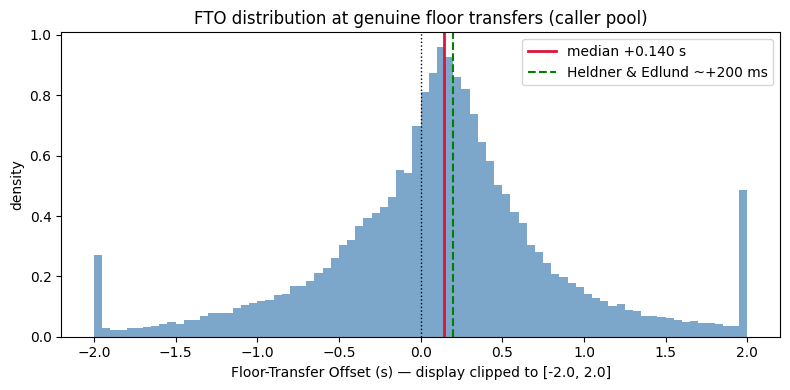

In [3]:
# FTO external-validity check (AUDIT.md §17). Genuine floor-transfer offsets should
# reproduce the canonical turn-taking distribution — a single mode just after zero
# (~+200 ms; Heldner & Edlund 2010; Levinson & Torreira 2015) with a ~1/3 overlap
# (negative) tail. This is the free external check the old Turn Gap flunked (median
# -0.49 s, 60% negative). Shown on ALL transfers (pre-window) to motivate the [-2,+2] cut.
_f = _fto["FTO Sec"].dropna().values
print(f"FTO at floor transfers: n={len(_f)}  |  median {np.median(_f):+.3f} s   "
      f"mean {_f.mean():+.3f} s  |  overlap (<0): {100*(_f < 0).mean():.1f}%  |  "
      f"within [-1, +2] s: {100*((_f >= -1) & (_f <= 2)).mean():.1f}%")
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(np.clip(_f, FTO_LO, FTO_HI), bins=80, color="steelblue", alpha=0.7, density=True)
ax.axvline(0, color="k", lw=1, ls=":")
ax.axvline(np.median(_f), color="crimson", lw=2, label=f"median {np.median(_f):+.3f} s")
ax.axvline(0.200, color="green", lw=1.5, ls="--", label="Heldner & Edlund ~+200 ms")
ax.set_xlabel(f"Floor-Transfer Offset (s) — display clipped to [{FTO_LO}, {FTO_HI}]")
ax.set_ylabel("density")
ax.set_title("FTO distribution at genuine floor transfers (caller pool)")
ax.legend(); plt.tight_layout(); plt.show()

## Step 2 — Flag backchannels & aggregate each caller to a profile

(Backchannel allowlist unchanged from 04 — its validation/sensitivity is a separate task.)

In [4]:
BC = {"yeah", "yea", "yep", "yup", "yes", "ya", "yah", "uh-huh", "uhhuh", "huh-uh", "um-hum",
      "umhum", "mm-hmm", "mm-hm", "mmhm", "mhm", "m-hm", "mm", "mmm", "hm", "hmm", "hmmm",
      "hum", "huh", "uh", "um", "er", "erm", "ah", "oh", "ooh", "aw", "okay", "ok", "right",
      "sure", "wow", "gosh"}

def is_backchannel(t):
    toks = [w.strip(string.punctuation).lower() for w in str(t).split()]
    toks = [w for w in toks if w]
    return len(toks) > 0 and all(w in BC for w in toks)

# --- Phase 0 (Continuum Validation Plan Q2): the shared unit-table builder --------------
# One parameterized path from the per-utterance frame to an analysis table, so the modality
# battery (Step 18), clusterability (Step 19), and the multiverse grid (Step 22) reuse the
# exact machinery Steps 2-3 are validated on instead of re-implementing it per step.
#   unit        : "caller" (speaker=caller_no) | "side" (sw####A/B) | "utterance"
#   bc_def      : "allowlist38" | "token<=2" | "union" | "none" | a precomputed boolean mask
#                 aligned to df.index (True = backchannel) — classifier/gold defs plug in here
#   transform   : "none" | "winsor_log1p" — winsorize [1,99] + log1p, applied per feature to
#                 NONNEGATIVE columns only and never to `FTO Sec` (signed offset); this is the
#                 §2.8 sensitivity arm, exercised in the Step 22 grid
#   min_utt     : per-unit reliability floor on substantive-utterance count
#                 (not applicable to unit="utterance")
#   feature_set : feature columns to aggregate (default: the vol11 block `feature_cols`)
# Aggregation = NaN-skipping mean over SUBSTANTIVE (non-backchannel) utterances; bc_rate over
# ALL utterances; demographics take each unit's first value. unit="utterance" returns the
# substantive rows complete on the feature set (count of NaN-dropped rows printed).

def build_unit_table(df, unit="caller", bc_def="allowlist38", transform="none",
                     min_utt=20, feature_set=None, verbose=True):
    feats = list(feature_cols if feature_set is None else feature_set)
    if isinstance(bc_def, str):
        if bc_def == "allowlist38":
            bc = df["Transcript"].apply(is_backchannel)
        elif bc_def == "token<=2":
            bc = df["token_count"] <= 2
        elif bc_def == "union":
            bc = df["Transcript"].apply(is_backchannel) | (df["token_count"] <= 2)
        elif bc_def == "none":
            bc = pd.Series(False, index=df.index)
        else:
            raise ValueError(f"unknown bc_def: {bc_def!r}")
    else:
        bc = pd.Series(bc_def, index=df.index).astype(bool)

    work = df.copy()
    work["is_bc"] = bc
    sub = work[~work["is_bc"]]

    if transform == "winsor_log1p":
        sub = sub.copy()
        for col in feats:
            v = sub[col]
            if col == "FTO Sec" or v.min(skipna=True) < 0:
                continue                     # never FTO; log1p needs nonnegative input
            lo, hi = v.quantile([0.01, 0.99])
            sub[col] = np.log1p(v.clip(lo, hi))
    elif transform != "none":
        raise ValueError(f"unknown transform: {transform!r}")

    if unit == "utterance":
        tbl = sub.dropna(subset=feats).copy()
        if verbose:
            print(f"Utterance unit: {len(tbl)} substantive utterances complete on the "
                  f"feature set (dropped {len(sub) - len(tbl)} with NaN)")
        return tbl

    key = {"caller": "speaker", "side": "side"}.get(unit)
    if key is None:
        raise ValueError(f"unknown unit: {unit!r}")
    tbl = sub.groupby(key)[feats].mean()
    tbl["n_sub"] = sub.groupby(key).size()
    if "FTO Sec" in sub.columns:
        tbl["n_fto"] = sub.groupby(key)["FTO Sec"].count()  # in-window floor transfers per unit
    tbl["bc_rate"] = work.groupby(key)["is_bc"].mean()
    for dcol in ["Gender", "Region", "Generation", "Education", "Year Born"]:
        tbl[dcol] = work.groupby(key)[dcol].first()
    if verbose:
        print(f"Substantive utterances/{unit}: median {int(tbl['n_sub'].median())}, "
              f"min {tbl['n_sub'].min()}, max {tbl['n_sub'].max()}")
        if "n_fto" in tbl:
            print(f"In-window FTO transfers/{unit}: median {int(tbl['n_fto'].median())}, "
                  f"min {int(tbl['n_fto'].min())}, max {int(tbl['n_fto'].max())}, "
                  f"{unit}s with <10: {int((tbl['n_fto'] < 10).sum())}")
    tbl = tbl[tbl["n_sub"] >= min_utt].copy()
    if verbose:
        print(f"{unit.capitalize()}s retained (>= {min_utt} substantive utterances): {len(tbl)}")
    return tbl

# Primary specification — the validated Steps 2-3 path (regression-gated against the
# 2026-06-30 run): caller / allowlist38 / no transform / min 20 / vol11.
MIN = 20  # reliability floor (nearly non-binding: caller pooling => median ~236 utts)
spk = build_unit_table(df, unit="caller", bc_def="allowlist38", transform="none",
                       min_utt=MIN, feature_set=feature_cols)

# Keep the primary backchannel flag + substantive view on df for later steps (Steps 11+
# consume `sub`; the mask is identical to the one build_unit_table just used).
df["is_bc"] = df["Transcript"].apply(is_backchannel)
sub = df[~df["is_bc"]]

Substantive utterances/caller: median 238, min 11, max 1590
In-window FTO transfers/caller: median 109, min 3, max 842, callers with <10: 21
Callers retained (>= 20 substantive utterances): 487


## Step 3 — PCA across callers (standardized per-caller means), 1-indexed PCs

In [5]:
# --- Phase 0: the PCA runner (paired with build_unit_table; reused by Steps 18/19/22) ---
def run_pca(tbl, features):
    """Standardize tbl[features] and fit a full-rank PCA. Returns (Xs, pca, scores)."""
    Xs = StandardScaler().fit_transform(tbl[list(features)].values)
    pca = PCA(n_components=len(features))
    scores = pca.fit_transform(Xs)
    return Xs, pca, scores

Xs, pca, scores = run_pca(spk, feature_cols)
n_pc = scores.shape[1]
for j in range(n_pc):                       # store conventional 1-indexed columns PC1..PCk
    spk[f"PC{j+1}"] = scores[:, j]
evr = pca.explained_variance_ratio_
print(f"Callers: {len(spk)} | features: {len(feature_cols)}")
print(f"PC1 explained variance: {evr[0]*100:.2f}%  | cumulative to PC3: {evr[:3].sum()*100:.1f}%")
load = (pd.DataFrame({"Feature": feature_cols, "Loading": pca.components_[0]})
        .assign(a=lambda d: d.Loading.abs()).sort_values("a", ascending=False))
print("\nPC1 loadings:")
for _, r in load.iterrows():
    print(f"  {r.Loading:+.4f}  {r.Feature}")

Callers: 487 | features: 11
PC1 explained variance: 42.55%  | cumulative to PC3: 78.5%

PC1 loadings:
  +0.4130  token_count
  +0.4094  Repetitions In Current Utterance
  +0.3972  word_rate
  +0.3847  syllable_rate
  +0.3311  Repetitions In Previous Utterance
  +0.3093  Pronouns per Second
  +0.1914  loudness mean
  +0.1914  Filler Words per Second
  +0.1875  loudness range
  +0.1719  loudness std
  -0.1134  FTO Sec


## Step 4 — How many components to keep? Horn's parallel analysis

PC1 explains only ~40%, so structure lives beyond it. Parallel analysis keeps a
component only if its eigenvalue exceeds the 95th percentile of eigenvalues from
random data of the same shape — a principled replacement for eyeballing the scree.

Parallel analysis (data eigenvalue vs 95th-pct of random):
  PC 1: eig=4.690  rand95=1.310  -> KEEP
  PC 2: eig=2.823  rand95=1.229  -> KEEP
  PC 3: eig=1.141  rand95=1.163  -> drop
  PC 4: eig=0.886  rand95=1.112  -> drop
  PC 5: eig=0.748  rand95=1.069  -> drop
  PC 6: eig=0.362  rand95=1.028  -> drop
  PC 7: eig=0.237  rand95=0.988  -> drop
  PC 8: eig=0.072  rand95=0.948  -> drop
  PC 9: eig=0.041  rand95=0.909  -> drop
  PC10: eig=0.020  rand95=0.868  -> drop
  PC11: eig=0.004  rand95=0.820  -> drop

Components retained: K=2   (Kaiser eig>1 would keep 3)


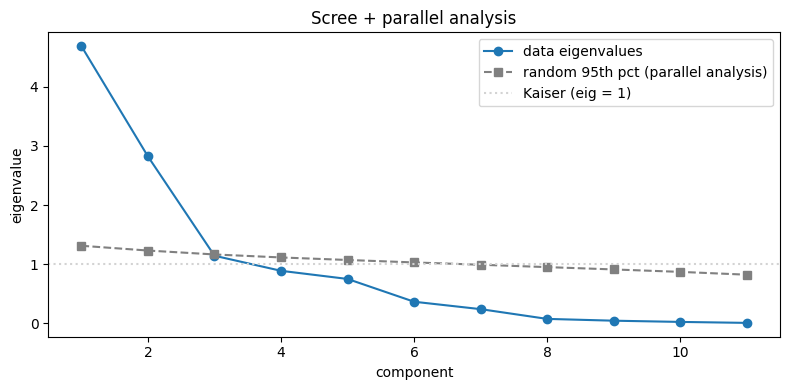

In [6]:
n, p = Xs.shape
eig_real = pca.explained_variance_                  # eigenvalues (standardized => correlation-matrix)
rng = np.random.default_rng(0)
N_ITER = 500
eig_rand = np.empty((N_ITER, p))
for i in range(N_ITER):
    Xr = StandardScaler().fit_transform(rng.standard_normal((n, p)))
    eig_rand[i] = PCA(n_components=p).fit(Xr).explained_variance_
thresh = np.percentile(eig_rand, 95, axis=0)
keep = eig_real > thresh
K = int(keep.sum())
print("Parallel analysis (data eigenvalue vs 95th-pct of random):")
for j in range(p):
    print(f"  PC{j+1:>2}: eig={eig_real[j]:.3f}  rand95={thresh[j]:.3f}  -> {'KEEP' if keep[j] else 'drop'}")
print(f"\nComponents retained: K={K}   (Kaiser eig>1 would keep {(eig_real>1).sum()})")

plt.figure(figsize=(8, 4))
plt.plot(range(1, p+1), eig_real, "o-", label="data eigenvalues")
plt.plot(range(1, p+1), thresh, "s--", color="gray", label="random 95th pct (parallel analysis)")
plt.axhline(1, color="lightgray", ls=":", label="Kaiser (eig = 1)")
plt.xlabel("component"); plt.ylabel("eigenvalue"); plt.title("Scree + parallel analysis")
plt.legend(); plt.tight_layout(); plt.show()

## Step 5 — Distribution shape of each retained PC (replaces silhouette)

For a continuum the question is "is each axis one smooth hump?", answered by skew +
**excess kurtosis** (0 = normal) and **Hartigan's dip test** (p > 0.05 = fail to
reject unimodality). Silhouette is gone — it only scores forced partitions. One GMM
BIC(k=1 vs k=2) line is kept as the direct answer to the old "BIC picked k=2".

In [7]:
print(f"{'PC':>4} {'skew':>7} {'exc.kurt':>9} {'dip':>7} {'dip p':>8}   KDE modes(.25/.4/.6)   verdict")
for j in range(K):
    v = scores[:, j]
    sk = skew(v); ku = kurtosis(v, fisher=True)          # excess kurtosis: 0 == normal
    dstat, dp = diptest(v)
    grid = np.linspace(v.min(), v.max(), 2000); modes = []
    for bw in (0.25, 0.40, 0.60):
        dens = gaussian_kde(v, bw_method=bw)(grid)
        modes.append(int(len(find_peaks(dens, prominence=dens.max()*0.05)[0])))
    verdict = "unimodal" if (dp > 0.05 and max(modes) == 1) else ("MULTIMODAL" if max(modes) > 1 else "unimodal*")
    print(f"PC{j+1:>2} {sk:>7.3f} {ku:>9.3f} {dstat:>7.4f} {dp:>8.3f}   {str(modes):>12}        {verdict}")

X1 = scores[:, [0]]
b1 = GaussianMixture(1, random_state=0).fit(X1).bic(X1)
b2 = GaussianMixture(2, random_state=0).fit(X1).bic(X1)
print(f"\nPC1 GMM BIC: k=1 {b1:.0f} | k=2 {b2:.0f} | dBIC(2-1) = {b2-b1:+.0f}"
      f"  ->  {'k=1 single component preferred' if b2 > b1 else 'k=2 preferred'}")
print("(dip p>0.05 AND single KDE mode AND BIC favouring k=1  =>  unimodal continuum)")

  PC    skew  exc.kurt     dip    dip p   KDE modes(.25/.4/.6)   verdict
PC 1   0.458     0.853  0.0096    0.994      [1, 1, 1]        unimodal
PC 2   1.159     2.677  0.0099    0.993      [1, 1, 1]        unimodal



PC1 GMM BIC: k=1 2146 | k=2 2157 | dBIC(2-1) = +11  ->  k=1 single component preferred
(dip p>0.05 AND single KDE mode AND BIC favouring k=1  =>  unimodal continuum)


## Step 6 — Visual normalness: histograms with a fitted-normal overlay

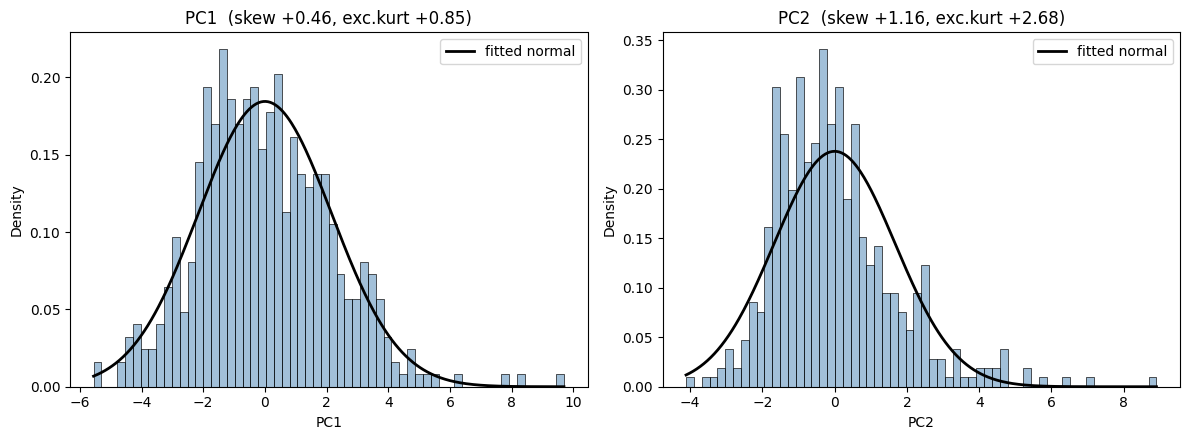

In [8]:
ncol = min(K, 3)
fig, axes = plt.subplots(1, ncol, figsize=(6*ncol, 4.5))
axes = np.atleast_1d(axes)
for j in range(ncol):
    v = scores[:, j]; ax = axes[j]
    sns.histplot(v, bins=60, stat="density", color="steelblue", alpha=0.5, ax=ax)
    xs = np.linspace(v.min(), v.max(), 400)
    ax.plot(xs, norm.pdf(xs, v.mean(), v.std()), "k-", lw=2, label="fitted normal")
    ax.set_title(f"PC{j+1}  (skew {skew(v):+.2f}, exc.kurt {kurtosis(v):+.2f})")
    ax.set_xlabel(f"PC{j+1}"); ax.legend()
plt.tight_layout(); plt.show()

## Step 7 — Sanity: PC1 is not just a backchannel/length artifact

In [9]:
pc1 = scores[:, 0]
print(f"PC1 correlation with backchannel rate: {np.corrcoef(pc1, spk['bc_rate'])[0,1]:+.3f}")
print(f"PC1 correlation with #utterances:      {np.corrcoef(pc1, spk['n_sub'])[0,1]:+.3f}")
print("(near zero => PC1 reflects volume style, not how many backchannels / utterances a caller has)")

PC1 correlation with backchannel rate: -0.070
PC1 correlation with #utterances:      +0.042
(near zero => PC1 reflects volume style, not how many backchannels / utterances a caller has)


## Step 8 — Demographics in PC space: mean ± SD ± n + significance (FDR-corrected)

Unit = **caller** (independent observations), so these tests are legitimate. Welch t
for gender (2 groups), one-way ANOVA for region/generation/education; Benjamini-
Hochberg FDR across the whole family of demographic×PC tests. Tiny groups (n<5) are
dropped from the test.

In [10]:
DEMOS = ["Gender", "Region", "Generation", "Education"]
rows = []
for dcol in DEMOS:
    for j in range(K):
        pcname = f"PC{j+1}"
        g = spk.groupby(dcol)[pcname].agg(["mean", "std", "count"])
        g = g[g["count"] >= 5].sort_values("mean")
        if len(g) < 2:
            continue
        if dcol == "Gender":
            grp = g.index.tolist()[:2]
            a = spk.loc[spk[dcol]==grp[0], pcname]; b = spk.loc[spk[dcol]==grp[1], pcname]
            stat, pval = ttest_ind(a, b, equal_var=False)
            dd = (a.mean()-b.mean()) / np.sqrt((a.var(ddof=1)+b.var(ddof=1))/2)
            rows.append((dcol, pcname, "Welch t", stat, pval, f"d={dd:+.2f}"))
        else:
            groups = [spk.loc[spk[dcol]==ix, pcname].values for ix in g.index]
            stat, pval = f_oneway(*groups)
            rows.append((dcol, pcname, "ANOVA F", stat, pval, f"{len(groups)} grps"))
        if j == 0:
            print(f"=== {dcol} on PC1 (mean +/- SD, n) ===")
            print(g.round(3).to_string()); print()

res = pd.DataFrame(rows, columns=["demographic", "PC", "test", "stat", "p_raw", "extra"])
res["p_fdr"] = bh_fdr(res["p_raw"].values)
res["sig"] = np.where(res["p_fdr"] < 0.05, "***", "")
print("Significance across all demographic x PC tests (BH-FDR):")
print(res.assign(stat=res["stat"].round(2),
                 p_raw=res["p_raw"].map(lambda x: f"{x:.1e}"),
                 p_fdr=res["p_fdr"].map(lambda x: f"{x:.1e}")).to_string(index=False))

=== Gender on PC1 (mean +/- SD, n) ===
         mean    std  count
Gender                     
female -0.454  1.986    232
male    0.413  2.242    255

=== Region on PC1 (mean +/- SD, n) ===
                mean    std  count
Region                            
western       -0.308  2.187     76
mixed         -0.242  1.344     26
south_midland -0.241  2.066    147
northern       0.017  2.189     69
southern       0.297  2.476     52
north_midland  0.361  2.225     69
new_england    0.452  2.520     18
nyc            0.514  2.090     30



=== Generation on PC1 (mean +/- SD, n) ===
               mean    std  count
Generation                       
Generation_X -0.200  2.185     83
Silent       -0.148  2.076    116
Baby_Boomer   0.131  2.187    286

=== Education on PC1 (mean +/- SD, n) ===
            mean    std  count
Education                     
1         -0.322  1.759     37
2         -0.193  2.123    278
3          0.338  2.203    162
0          1.700  4.020      6

Significance across all demographic x PC tests (BH-FDR):
demographic  PC    test  stat   p_raw   extra   p_fdr sig
     Gender PC1 Welch t -4.52 7.6e-06 d=-0.41 6.1e-05 ***
     Gender PC2 Welch t -3.01 2.7e-03 d=-0.27 1.1e-02 ***
     Region PC1 ANOVA F  1.30 2.5e-01  8 grps 4.0e-01    
     Region PC2 ANOVA F  0.63 7.3e-01  8 grps 7.3e-01    
 Generation PC1 ANOVA F  1.15 3.2e-01  3 grps 4.2e-01    
 Generation PC2 ANOVA F  0.86 4.2e-01  3 grps 4.8e-01    
  Education PC1 ANOVA F  3.60 1.4e-02  4 grps 3.6e-02 ***
  Education PC2 ANOVA F  1.83 1.4e-0

## Step 8b — Education robustness (drop the unknown bucket)

Education code `0` is a tiny (n=6), wildly-variable group (mean +1.77 ± 4.09) — almost
certainly "unknown/unreported", not a real level. Re-run the Education ANOVA without it
to check the effect isn't an artifact of that bucket.

In [11]:
EDU_DROP = {0}          # unknown/unreported (code 9, n=4, is already excluded by n>=5)
sub_edu = spk[~spk["Education"].isin(EDU_DROP)]
print(f"Education levels used (n>=5, excluding unknown {sorted(EDU_DROP)}):\n")
for j in range(K):
    pcname = f"PC{j+1}"
    g = sub_edu.groupby("Education")[pcname].agg(["mean", "std", "count"])
    g = g[g["count"] >= 5]
    groups = [sub_edu.loc[sub_edu["Education"]==e, pcname].values for e in g.index]
    F, pp = f_oneway(*groups)
    with0 = res[(res["demographic"]=="Education") & (res["PC"]==pcname)]["p_raw"]
    p_with = with0.iloc[0] if len(with0) else float("nan")
    if j == 0:
        print(g.round(3).to_string()); print()
    print(f"  {pcname}: ANOVA F={F:.2f}  p={pp:.3f}   (with code 0: p={p_with:.3f})"
          f"   -> {'survives' if pp < 0.05 else 'not sig'}")
print("\n(PC1 shows a monotonic 1<2<3 level trend => graded effect, not an n=6 outlier.)")

Education levels used (n>=5, excluding unknown [0]):

            mean    std  count
Education                     
1         -0.322  1.759     37
2         -0.193  2.123    278
3          0.338  2.203    162

  PC1: ANOVA F=3.59  p=0.028   (with code 0: p=0.014)   -> survives
  PC2: ANOVA F=0.08  p=0.923   (with code 0: p=0.140)   -> not sig

(PC1 shows a monotonic 1<2<3 level trend => graded effect, not an n=6 outlier.)


## Step 9 — Group differences overlaid on the distribution (paper figure)

Per-group density curves drawn over the pooled PC1 histogram, with each group's mean
marked. This is the figure for the write-up: it shows *where* a group sits on the
continuum and how much the groups overlap (i.e. how real the difference is).

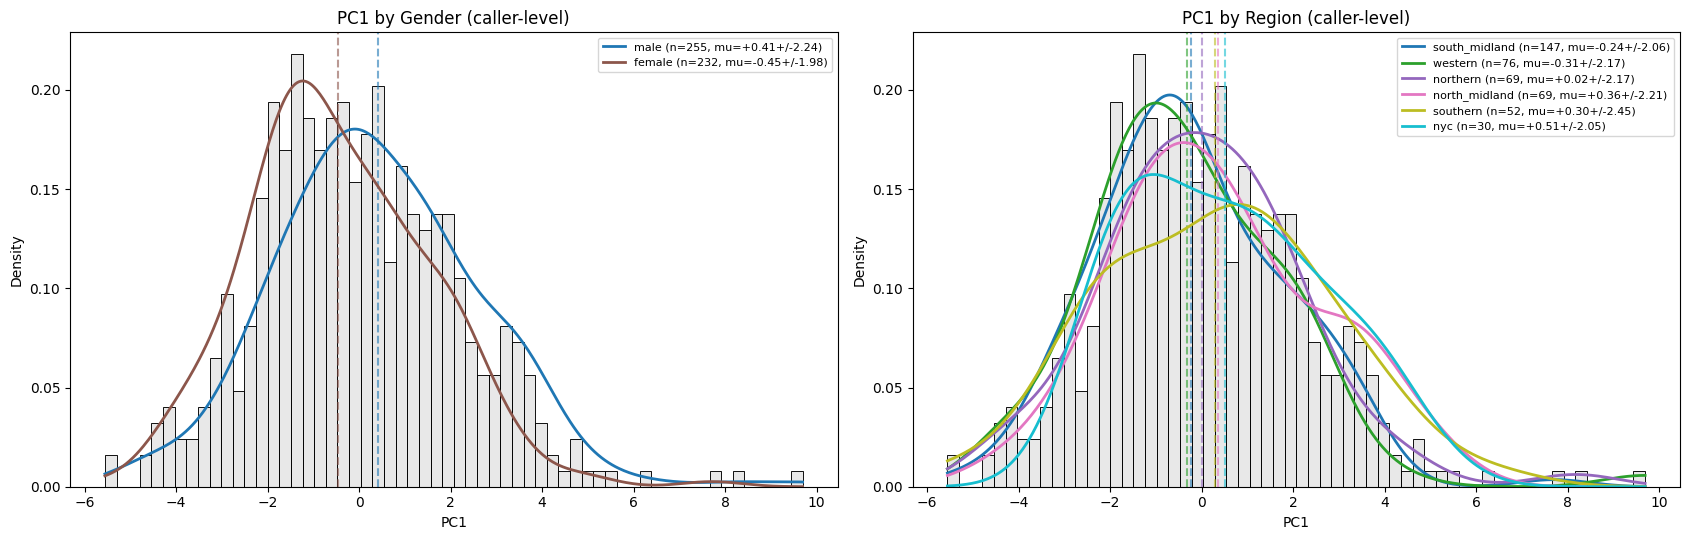

In [12]:
def overlay(ax, dcol, pcname="PC1", top=None):
    v = spk[pcname].values
    sns.histplot(v, bins=60, stat="density", color="lightgray", alpha=0.5, ax=ax)
    vc = spk[dcol].value_counts()
    cats = list(vc.index if top is None else vc.head(top).index)
    xs = np.linspace(v.min(), v.max(), 400)
    cmap = plt.cm.tab10(np.linspace(0, 1, max(len(cats), 3)))
    for c, col in zip(cats, cmap):
        vg = spk.loc[spk[dcol]==c, pcname].values
        if len(vg) < 5:
            continue
        ax.plot(xs, gaussian_kde(vg)(xs), color=col, lw=2,
                label=f"{c} (n={len(vg)}, mu={vg.mean():+.2f}+/-{vg.std():.2f})")
        ax.axvline(vg.mean(), color=col, ls="--", alpha=0.6)
    ax.set_title(f"{pcname} by {dcol} (caller-level)"); ax.set_xlabel(pcname)
    ax.legend(fontsize=8)

fig, axes = plt.subplots(1, 2, figsize=(17, 5.5))
overlay(axes[0], "Gender")
overlay(axes[1], "Region", top=6)
plt.tight_layout(); plt.show()

## Step 11 — Trust-adjudication evidence for the battery's inputs (submission plan T3; audit C1)

The printed evidence behind the 2026-07-09 `docs/FEATURES.md` registry moves: every column the
§4A battery (Step 18+) and the involvement panel will consume is checked here — **Tier 1**
(NB07's live volume features: the two repetition counters + filler rate), **Tier 2** (the FTO
helper columns), the **interactional subset** F_int uses (latching, overlap, within-pause),
**laughter** (full-corpus bracket reconciliation), the **pooled personal-focus** ingredients
(the sanctioned pool-then-ratio estimator, with the degenerate per-utterance score recomputed
inline as the contrast), and the **rising-terminal missingness audit** (MNAR by design + the
recorded slope clip bound). Decision rules were fixed in advance (audit C1); a failed hard
check reverts the corresponding registry move and batches an extractor fix per P1 — never an
inline patch. Validation-only reads here are exempt from the Step-10 consumption self-check.

In [13]:
# --- Tier 1: the live volume features (repetition counters + filler rate) ---------------
from swb_extract.features.repetitions_in_current import compute as pair_count
from swb_extract.features.filler_word_rate import DEFAULT_FILLERS

T3_CHECKS = {}                                   # hard-invariant ledger for this step
RC, RP = "Repetitions In Current Utterance", "Repetitions In Previous Utterance"
df["conv"] = df["side"].str[:6]                  # sw#### conversation id

# (1) Pair-count semantics: argmax rows + full-corpus recompute from the Transcript.
print(f"argmax {RC} — extractor value vs C(n,2) recomputed from the transcript:")
for _, r in df.nlargest(3, RC)[["Utterance File Name", RC, "token_count", "Transcript"]].iterrows():
    rec = pair_count(r["Transcript"])
    print(f"  {r['Utterance File Name']}  val={int(r[RC])}  recomputed={rec}  "
          f"tokens={int(r['token_count'])}  {'OK' if int(r[RC]) == rec else 'MISMATCH'}")
    print(f'    "{str(r["Transcript"])[:100]}"')
_mism = int((df["Transcript"].map(pair_count) != df[RC]).sum())
T3_CHECKS["pair-count recon mismatches"] = _mism
print(f"Full-corpus C(n,2) reconciliation: {_mism} mismatches / {len(df)} rows "
      f"(max {int(df[RC].max())} > max token_count {int(df['token_count'].max())} = the quadratic "
      f"tail, BY DESIGN — boundary unit test pins C(15,2)=105)")

# (2) Previous-utterance counter: nulls should be the conversation-initial rows.
_null_rp = df[df[RP].isna()]
print(f"{RP}: {len(_null_rp)} nulls ({100*len(_null_rp)/len(df):.2f}%) across "
      f"{_null_rp['conv'].nunique()} conversations (data has {df['conv'].nunique()}); "
      f"max nulls/conversation = {int(_null_rp.groupby('conv').size().max())} "
      f"(expect 1 = the merged-chronology-initial utterance)")

# (3) Filler + per-second variants: documented-design facts, recorded as registry notes.
print(f"Filler allowlist (verified vs docstring): {sorted(DEFAULT_FILLERS)}")
print("  → filled pauses (uh/um/er) and discourse markers (so/well/like/you know/i mean/i guess/basically)")
print("    share ONE bucket; opposite theoretical signs may cancel (audit §4E-c) — construct limitation, not a bug.")
print("Repetitions per Second: numerator = repetition_rate count (unique words reaching ≥2), NOT the")
print("  pair count — by design per its docstring; tokenization shared across the repetition family.")

argmax Repetitions In Current Utterance — extractor value vs C(n,2) recomputed from the transcript:
  223/sw2231B-U0011.wav  val=109  recomputed=109  tokens=64  OK
    "because_1 if they turn around they can get away they get away with it and they get away with it and "
  234/sw2342B-U0096.wav  val=99  recomputed=99  tokens=59  OK
    "right that that's actually the part that that that i find really strange i mean i i i sort of unders"
  356/sw3564B-U0050.wav  val=93  recomputed=93  tokens=70  OK
    "you know and so so i you know i tried to jump start it i couldn't get it in it still i mean had some"


Full-corpus C(n,2) reconciliation: 0 mismatches / 214204 rows (max 109 > max token_count 81 = the quadratic tail, BY DESIGN — boundary unit test pins C(15,2)=105)
Repetitions In Previous Utterance: 1994 nulls (0.93%) across 1994 conversations (data has 1994); max nulls/conversation = 1 (expect 1 = the merged-chronology-initial utterance)
Filler allowlist (verified vs docstring): ['basically', 'er', 'i guess', 'i mean', 'like', 'so', 'uh', 'um', 'well', 'you know']
  → filled pauses (uh/um/er) and discourse markers (so/well/like/you know/i mean/i guess/basically)
    share ONE bucket; opposite theoretical signs may cancel (audit §4E-c) — construct limitation, not a bug.
Repetitions per Second: numerator = repetition_rate count (unique words reaching ≥2), NOT the
  pair count — by design per its docstring; tokenization shared across the repetition family.


In [14]:
# --- Tier 2: FTO helper columns (Onset Gap, Turn Initial / Backchannel / Interjection) --
# Join the RAW pre-window FTO back on (cell `c03` masked df["FTO Sec"] to [-2,+2] s; the
# extractor-level invariants below are about raw floor transfers).
h = df.merge(_fto.rename(columns={"FTO Sec": "fto_raw"}), on="Utterance File Name", how="left")
ti, bcf, og = h["Turn Initial Flag"], h["Backchannel Flag"], h["Onset Gap Sec"]

v1 = int((h["fto_raw"].notna() & (ti != 1)).sum())
T3_CHECKS["FTO defined ⇒ turn-initial"] = v1
print(f"FTO defined ⇒ Turn Initial=1: violations = {v1} / {int(h['fto_raw'].notna().sum())} raw transfers")
_ti_nofto = int((ti.eq(1) & h["fto_raw"].isna()).sum())
print(f"Turn-initial without FTO = {_ti_nofto} vs {h['conv'].nunique()} conversations "
      f"(the conversation-opening turn has no transfer to time — expect ≈1 per conversation)")

agree = (bcf == h["is_bc"].astype(int)).mean()
print(f"Backchannel Flag vs notebook allowlist is_bc: agreement {100*agree:.2f}% | rates "
      f"{100*bcf.eq(1).mean():.1f}% vs {100*h['is_bc'].mean():.1f}% "
      f"(lexical twin by construction — NXT gold P/R lands in Step 12)")

n_og = og.isna()
print(f"Onset Gap Sec null {100*n_og.mean():.1f}% — of the nulls: backchannel rows "
      f"{100*(n_og & h['is_bc']).sum()/n_og.sum():.1f}%, non-bc (conversation-initial/unplaceable) "
      f"{100*(n_og & ~h['is_bc']).sum()/n_og.sum():.1f}% "
      f"(docstring: empty for backchannels + conversation-initial turns)")

FTO defined ⇒ Turn Initial=1: violations = 0 / 76000 raw transfers
Turn-initial without FTO = 1994 vs 1994 conversations (the conversation-opening turn has no transfer to time — expect ≈1 per conversation)
Backchannel Flag vs notebook allowlist is_bc: agreement 100.00% | rates 25.1% vs 25.1% (lexical twin by construction — NXT gold P/R lands in Step 12)
Onset Gap Sec null 25.4% — of the nulls: backchannel rows 96.3%, non-bc (conversation-initial/unplaceable) 3.7% (docstring: empty for backchannels + conversation-initial turns)


In [15]:
# --- Tier-4 subset: latching, overlap, within-utterance pauses --------------------------
lf = h["Latching Flag"]; d_l = lf.notna()
v_l = int((lf.eq(1) & ~h["fto_raw"].between(0.0, 0.2)).sum())
T3_CHECKS["latch ⇒ FTO∈[0,0.2]"] = v_l
print(f"Latching: defined {100*d_l.mean():.1f}% (transfers only) | latched among defined "
      f"{100*lf[d_l].eq(1).mean():.1f}% (registry: 17.8%) | Latching=1 ⇒ raw FTO∈[0,0.2]s violations = {v_l}")

oo = h["Overlap Onset Flag"]; ti1 = h["Turn Initial Flag"].eq(1)
r_neg = oo[ti1 & h["fto_raw"].lt(0)].eq(1).mean()
r_pos = oo[ti1 & h["fto_raw"].ge(0)].eq(1).mean()
print(f"Overlap Onset at floor transfers: FTO<0 → {100*r_neg:.1f}% flagged vs FTO≥0 → {100*r_pos:.1f}% "
      f"(coheres with Step 1b's 37.7% overlap tail; word-tight FTO vs mid-word onset differ at edges by design)")

wt, wc, wr, wm = (h["Within Pause Total Sec"], h["Within Pause Count"],
                  h["Within Pause Rate"], h["Max Within Pause Sec"])
d_w = wt.notna()
inv = {
    "pause Total ≥ Max": int((wt[d_w] < wm[d_w] - 1e-9).sum()),
    "pause Count≥1 ⇒ Max≥0.25": int((wc[d_w].ge(1) & wm[d_w].lt(0.25)).sum()),
    "pause Count=0 ⇒ Max<0.25": int((wc[d_w].eq(0) & wm[d_w].ge(0.25)).sum()),
    "pause Rate ≤ 1": int((wr[d_w] > 1 + 1e-9).sum()),
}
T3_CHECKS.update(inv)
print(f"Within-pause: defined {100*d_w.mean():.1f}% | zero-inflation: Count=0 on "
      f"{100*wc[d_w].eq(0).mean():.1f}% of defined")
print("  invariant violations: " + " | ".join(f"{k}: {v}" for k, v in inv.items()))
print("  (note: Total sums ALL positive gaps, Count only those ≥0.25 s — so Count=0 ⇏ Total=0; "
      "this corrects C1's guessed invariant)")

Latching: defined 35.5% (transfers only) | latched among defined 17.9% (registry: 17.8%) | Latching=1 ⇒ raw FTO∈[0,0.2]s violations = 0
Overlap Onset at floor transfers: FTO<0 → 87.0% flagged vs FTO≥0 → 0.0% (coheres with Step 1b's 37.7% overlap tail; word-tight FTO vs mid-word onset differ at edges by design)
Within-pause: defined 100.0% | zero-inflation: Count=0 on 62.6% of defined
  invariant violations: pause Total ≥ Max: 0 | pause Count≥1 ⇒ Max≥0.25: 0 | pause Count=0 ⇒ Max<0.25: 0 | pause Rate ≤ 1: 0
  (note: Total sums ALL positive gaps, Count only those ≥0.25 s — so Count=0 ⇏ Total=0; this corrects C1's guessed invariant)


In [16]:
# --- Laughter: full-corpus reconciliation against the bracket-preserving Transcript -----
toks = df["Transcript"].str.split()
rec_l = toks.map(lambda ws: sum(1 for w in ws if w == "[laughter]"))
rec_lw = toks.map(lambda ws: sum(1 for w in ws if w.startswith("[laughter-") and w.endswith("]")))
m_l = int((rec_l != df["Laughter Count"]).sum()); m_lw = int((rec_lw != df["Laughed Word Count"]).sum())
T3_CHECKS["laughter recon mismatches"] = m_l + m_lw
print(f"Laughter reconciliation (all {len(df)} rows): Laughter Count mismatches={m_l}, "
      f"Laughed Word Count mismatches={m_lw} | any-laughter incidence "
      f"{100*((df['Laughter Count'] + df['Laughed Word Count']) > 0).mean():.1f}% (Jun-19 survey ≈7.5%)")

# --- Pooled personal focus: the sanctioned estimator + why (Pipeline A1 evidence) --------
ph, ih = sub.groupby("speaker")["Personal Hits"].sum(), sub.groupby("speaker")["Impersonal Hits"].sum()
tot = (ph + ih).reindex(spk.index)
for floor in (10, 30, 100):
    print(f"  PF coverage at ≥{floor} pooled hits: {100*(tot >= floor).mean():.1f}% of {len(spk)} retained callers")
pf = (ph.reindex(spk.index) / tot)[tot >= 30]
print(f"  PF_ratio (floor 30): n={len(pf)}  mean {pf.mean():.3f}  sd {pf.std():.3f}  "
      f"skew {skew(pf):+.2f}  saturated exactly 0/1: {int(((pf == 0) | (pf == 1)).sum())}  → non-degenerate")
ut = df["Personal Hits"] + df["Impersonal Hits"]
us = (df["Personal Hits"] / ut).where(ut >= 3)
print(f"  contrast — per-utterance gated score (recomputed inline): null {100*us.isna().mean():.1f}% "
      f"(Jun-19: 71.5%), exactly 0/1 among defined {100*((us == 0) | (us == 1)).sum()/us.notna().sum():.1f}% "
      f"(Jun-19: 48.6%) → the degenerate estimator; column Deprecated, pool-then-ratio is the sanctioned use")

# --- Rising terminal: missingness audit (MNAR) + slope clip bound -----------------------
rt, slp = df["Rising Terminal Flag"], df["Terminal F0 Slope"]
_lens = [("≤2 tok", df["token_count"].le(2)), ("3–5", df["token_count"].between(3, 5)),
         ("≥6", df["token_count"].ge(6))]
by_len = " / ".join(f"{lab} {100*rt[m].isna().mean():.0f}%" for lab, m in _lens)
print(f"Rising Terminal: null {100*rt.isna().mean():.1f}% overall — by utterance length: {by_len} "
      f"→ MNAR, voicing/length-dependent. NOTE the null rate RISES with length (21→35%), contra the "
      f"docstring's short-tails attribution — long utterances end unvoiced/trailing-off more often, "
      f"short backchannel-like ones end voiced. Never fillna(0): null = indeterminate.")
q = slp.quantile([0.01, 0.5, 0.99])
print(f"  rising among defined: {100*rt.eq(1).sum()/rt.notna().sum():.1f}% | Terminal F0 Slope "
      f"p1 {q.iloc[0]:+.0f} / med {q.iloc[1]:+.0f} / p99 {q.iloc[2]:+.0f} Hz/s; "
      f"|slope|>1000 Hz/s: {100*slp.abs().gt(1000).mean():.2f}% → clip bound ±1000 Hz/s recorded")

_fails = {k: v for k, v in T3_CHECKS.items() if v != 0}
if _fails:
    print(f"\nSTEP 11 VERDICT: CHECK FAILURES {_fails} — revert the matching registry moves and batch a fix per P1.")
else:
    print(f"\nSTEP 11 VERDICT: all {len(T3_CHECKS)} hard invariants at 0 violations → 26 registry rows "
          "promoted WIP→Trusted (Tier-1 ×4, FTO helpers ×4, latching/overlap/pause ×8, laughter ×5, "
          "PF ingredients ×3, rising-terminal ×2); per-utterance Personal Focus Score → Deprecated. "
          "docs/FEATURES.md carries these outputs as the evidence notes. "
          "(First run of this step caught a stale pre-Jun-26-FTO vintage in latching_flag.csv — "
          "3 visible violations, 1,333 rows corrected on re-extraction 2026-07-09.)")

Laughter reconciliation (all 214204 rows): Laughter Count mismatches=0, Laughed Word Count mismatches=0 | any-laughter incidence 7.5% (Jun-19 survey ≈7.5%)
  PF coverage at ≥10 pooled hits: 100.0% of 487 retained callers
  PF coverage at ≥30 pooled hits: 100.0% of 487 retained callers
  PF coverage at ≥100 pooled hits: 93.4% of 487 retained callers
  PF_ratio (floor 30): n=487  mean 0.619  sd 0.129  skew -0.28  saturated exactly 0/1: 0  → non-degenerate
  contrast — per-utterance gated score (recomputed inline): null 71.5% (Jun-19: 71.5%), exactly 0/1 among defined 48.6% (Jun-19: 48.6%) → the degenerate estimator; column Deprecated, pool-then-ratio is the sanctioned use
Rising Terminal: null 30.3% overall — by utterance length: ≤2 tok 21% / 3–5 31% / ≥6 35% → MNAR, voicing/length-dependent. NOTE the null rate RISES with length (21→35%), contra the docstring's short-tails attribution — long utterances end unvoiced/trailing-off more often, short backchannel-like ones end voiced. Never fi

## Step 12 — NXT gold validation: dialog-act alignment, backchannels, questions (T4; audit D3/§4C12a-b)

Gold = SWBD-DAMSL dialog acts in NXT form, 642 conversations on disk (`corpus/nxt_switchboard_ann/`),
parsed by `swb_extract.nxt` (unit-tested; spans resolved through the terminals layer). Citations:
Jurafsky, Shriberg & Biasca 1997 (coders manual, TR 97-02); Stolcke et al. 2000, *Comp. Ling.* 26(3);
Calhoun et al. 2010, *LREC J.* 44(4) (the resource); Shriberg et al. 1998, *Lang. & Speech* 41(3–4)
(prosody marks declarative questions — the Rising-Terminal bridge).

**Pre-registered decisions (fixed before any number below was computed):**
- **Alignment:** each timed gold DA → the same-side ms98 utterance with maximal temporal overlap,
  accepted iff overlap ≥ 50% of the shorter span. Expected match rate >90%; investigate below that.
- **Tag membership by `parse_tag` base+decorations, never string equality.**
- **Gold backchannel:** primary = base `b`; sensitivity variant = bases {`b`,`bh`,`bk`}. An
  utterance is gold-bc iff it matched ≥1 DA and ALL its matched DAs are in the set (mirrors the
  allowlist's all-tokens rule). `+` continuations count as non-bc content.
- **Gold question:** bases {`qy`,`qw`,`qo`,`qh`,`qrr`,`qr`} ∪ the decoration-only tag-question act
  `^g`. An utterance is gold-q iff ANY matched DA is in the set. Declarative = `^d` decoration.
- **Admission bar (Delta 5/6):** `question_rate` joins the involvement panel iff heuristic
  precision ≥ 0.8 with an understood, quantified recall deficit; otherwise excluded and the gold
  rate is reported descriptively.
- Everything in this step is **validation-only** — no column joins `EXTRA_CONSUMED`.

In [17]:
# --- 12a: parse the gold, align DAs to our utterances, print the inventory --------------
import time as _time
from collections import Counter as _Counter
from pathlib import Path

from swb_extract import nxt
from swb_extract.transcripts import parse_transcript

_t0 = _time.time()
TRANS_ROOT = Path("../swb_ms98_transcriptions_cleaned")
_gold_convs = nxt.list_conversations()
CONVS = sorted(set(_gold_convs) & {int(c[2:]) for c in df["conv"].unique()})
print(f"NXT gold conversations: {len(_gold_convs)} | intersecting the manifest: {len(CONVS)}")

_rows, _inv_base, _inv_deco = [], _Counter(), _Counter()
_n_das = _n_untimed = _missing_files = 0
for _conv in CONVS:
    for _side in ("A", "B"):
        _tp = TRANS_ROOT / str(_conv)[:2] / str(_conv) / f"sw{_conv}{_side}-ms98-a-trans.text"
        if not _tp.is_file():
            _missing_files += 1
            continue
        _utts = list(parse_transcript(_tp))
        _keys = [f"{u.call_id//10:03d}/sw{u.call_id:04d}{u.side}-U{u.utt_num:04d}.wav" for u in _utts]
        _spans = [(u.start, u.end) for u in _utts]
        _das = nxt.load_dialacts(_conv, _side)
        _n_das += len(_das)
        for _d in _das:
            _inv_base.update(_d.bases); _inv_deco.update(_d.decorations)
        _timed = [d for d in _das if d.start is not None]
        _n_untimed += len(_das) - len(_timed)
        for _d, _mi in zip(_timed, nxt.align_to_utterances([(d.start, d.end) for d in _timed], _spans)):
            _rows.append((_conv, _side, _d.swbd_type, _d.bases, _d.decorations,
                          _d.start, _d.end, _keys[_mi] if _mi is not None else None))

gold = pd.DataFrame(_rows, columns=["conv", "side", "swbd", "bases", "decos",
                                    "g_start", "g_end", "utt_key"])
print(f"gold DAs parsed: {_n_das} ({_n_untimed} untimed, skipped; {_missing_files} sides lacked a transcript)")
print(f"DA→utterance match rate: {100*gold['utt_key'].notna().mean():.1f}%  "
      f"({int(gold['utt_key'].notna().sum())}/{len(gold)} timed DAs)   [{_time.time()-_t0:.0f}s]")
print("\nBASE-tag inventory (full, decorations stripped):")
print("  " + "  ".join(f"{b}:{n}" for b, n in _inv_base.most_common()))
print("\nDecoration inventory (full):")
print("  " + "  ".join(f"{d}:{n}" for d, n in _inv_deco.most_common()))

NXT gold conversations: 642 | intersecting the manifest: 544


gold DAs parsed: 104619 (925 untimed, skipped; 0 sides lacked a transcript)
DA→utterance match rate: 99.2%  (102817/103694 timed DAs)   [4s]

BASE-tag inventory (full, decorations stripped):
  sd:36493  b:17726  sv:12022  +:8471  %-:6526  aa:5653  qy:2828  ba:2366  ny:1489  fc:1390  %:1293  qw:1073  bk:713  nn:666  bh:581  h:572  ^q:475  bf:457  na:403  o:397  ad:344  qo:319  ^h:300  ^2:297  qh:271  ar:201  no:165  ng:132  br:126  fp:119  qr:106  nd:101  qrr:95  fe:71  t3:51  t1:39  fa:38  bd:38  co:35  ft:31  aap:30  am:25  ^g:20  cc:16  ":14  arp:13  fx:7  by:7  fo:5  bc:4  oo:4  fw:2

Decoration inventory (full):
  ^r:1821  ^e:1032  (^q):805  ^d:667  ^t:643  ^m:577  @:437  ^g:259  ^c:54  *:45  ^h:24  ^2:14


In [18]:
# --- 12b: utterance-level gold labels + backchannel allowlist P/R (Delta 7a) ------------
Q_BASES = {"qy", "qw", "qo", "qh", "qrr", "qr", "^g"}
BC_PRIMARY = {"b"}
BC_WIDE = {"b", "bh", "bk"}

_m = gold.dropna(subset=["utt_key"])
_by_utt = _m.groupby("utt_key")["bases"].agg(lambda s: [b for t in s for b in t])
utt_gold = pd.DataFrame({
    "gold_bases": _by_utt,
    "gold_q": _by_utt.map(lambda bs: any(b in Q_BASES for b in bs)),
    "gold_bc": _by_utt.map(lambda bs: len(bs) > 0 and set(bs) <= BC_PRIMARY),
    "gold_bc_wide": _by_utt.map(lambda bs: len(bs) > 0 and set(bs) <= BC_WIDE),
})
lab = df.merge(utt_gold, left_on="Utterance File Name", right_index=True, how="inner")
_subset_n = int(df["conv"].isin([f"sw{c}" for c in CONVS]).sum())
print(f"gold-labelled utterances: {len(lab)} of {_subset_n} manifest utterances in the 642-conv subset")

def prf(pred, gold_):
    tp = int((pred & gold_).sum()); fp = int((pred & ~gold_).sum()); fn = int((~pred & gold_).sum())
    p = tp / (tp + fp) if tp + fp else float("nan")
    r = tp / (tp + fn) if tp + fn else float("nan")
    f1 = 2 * p * r / (p + r) if p + r else float("nan")
    return p, r, f1, tp, fp, fn

for _name, _col in (("primary {b}", "gold_bc"), ("wide {b,bh,bk}", "gold_bc_wide")):
    p, r, f1, tp, fp, fn = prf(lab["is_bc"], lab[_col])
    print(f"allowlist-38 vs gold-bc {_name}:  precision {p:.3f}  recall {r:.3f}  F1 {f1:.3f}   "
          f"(tp {tp} fp {fp} fn {fn}; gold rate {100*lab[_col].mean():.1f}% vs allowlist {100*lab['is_bc'].mean():.1f}%)")

gold-labelled utterances: 52890 of 56927 manifest utterances in the 642-conv subset
allowlist-38 vs gold-bc primary {b}:  precision 0.842  recall 0.917  F1 0.878   (tp 10892 fp 2050 fn 983; gold rate 22.5% vs allowlist 24.5%)
allowlist-38 vs gold-bc wide {b,bh,bk}:  precision 0.864  recall 0.883  F1 0.873   (tp 11183 fp 1759 fn 1483; gold rate 23.9% vs allowlist 24.5%)


In [19]:
# --- 12c: question-flag validation — P/R, miss decomposition, counterfactual, RT bridge --
from swb_extract.features.question_flags import AUX_STARTERS, WH_WORDS, _content_tokens

qflag = lab["Question Flag"].fillna(0).astype(int).astype(bool)
p, r, f1, tp, fp, fn = prf(qflag, lab["gold_q"])
print(f"Question Flag vs gold questions:  precision {p:.3f}  recall {r:.3f}  F1 {f1:.3f}   "
      f"(gold-q rate {100*lab['gold_q'].mean():.2f}% vs flag rate {100*qflag.mean():.2f}% on the gold subset)")

# recall by question category at the DA level — the declarative-question hypothesis
_qda = _m[_m["bases"].map(lambda t: any(b in Q_BASES for b in t))].copy()
_qda["flagged"] = _qda["utt_key"].map(df.set_index("Utterance File Name")["Question Flag"]).fillna(0).astype(int)
_qda["cat"] = np.where(_qda["decos"].map(lambda d: "^d" in d), "declarative (^d)",
               np.where(_qda["bases"].map(lambda t: "^g" in t) | _qda["decos"].map(lambda d: "^g" in d),
                        "tag (^g)", "syntactic"))
print("\nrecall by gold question category (DA level):")
for _cat, _g in _qda.groupby("cat"):
    print(f"  {_cat:18s} n={len(_g):5d}  recall {100*_g['flagged'].mean():5.1f}%")

# leading-discourse-marker counterfactual (Tier-3 evidence; list fixed here)
_MARKERS = {"so", "well", "and", "but", "or", "oh", "now", "then", "um", "uh",
            "okay", "ok", "yeah", "right", "like"}
def _flag_after_marker_skip(text):
    toks = _content_tokens(text)
    i = 0
    while i < len(toks) and toks[i] in _MARKERS:
        i += 1
    return i < len(toks) and (toks[i] in WH_WORDS or toks[i] in AUX_STARTERS)

_fnu = lab[~qflag & lab["gold_q"]]
_tnu = lab[~qflag & ~lab["gold_q"]]
_gain = int(_fnu["Transcript"].map(_flag_after_marker_skip).sum())
_cost = int(_tnu["Transcript"].map(_flag_after_marker_skip).sum())
print(f"\nmarker-skip counterfactual: +{_gain} of {len(_fnu)} missed gold-q utterances would flip to flagged; "
      f"cost: +{_cost} new false flags among {len(_tnu)} gold-non-q unflagged")

# the prosody bridge: (Question Flag OR Rising Terminal)
_qrt = qflag | lab["Rising Terminal Flag"].eq(1)
p2, r2, f2, *_ = prf(_qrt, lab["gold_q"])
print(f"(Question Flag OR Rising Terminal): precision {p2:.3f}  recall {r2:.3f}  "
      f"(recall recovered vs flag alone: +{100*(r2-r):.1f} pts — Shriberg et al. 1998)")

# false-positive anatomy + echo-question one-liner
_fpu = lab[qflag & ~lab["gold_q"]]
_cnt = _Counter(b for bs in _fpu["gold_bases"] for b in set(bs))
print(f"\nfalse-positive utterances' gold tags (top 8): {dict(_cnt.most_common(8))}")
for _, _r in _fpu.head(3).iterrows():
    print(f'   e.g. [{"/".join(sorted(set(_r["gold_bases"])))}] "{str(_r["Transcript"])[:80]}"')
pe, re_, fe, *_ = prf(lab["Echo Question Flag"].eq(1), lab["gold_bases"].map(lambda bs: "bh" in bs))
print(f"Echo Question Flag vs gold bh (backchannel-in-question-form): precision {pe:.3f} recall {re_:.3f}")

Question Flag vs gold questions:  precision 0.553  recall 0.236  F1 0.331   (gold-q rate 7.83% vs flag rate 3.34% on the gold subset)

recall by gold question category (DA level):
  declarative (^d)   n=  657  recall   5.6%
  syntactic          n= 3735  recall  29.2%
  tag (^g)           n=  268  recall   3.4%

marker-skip counterfactual: +716 of 3165 missed gold-q utterances would flip to flagged; cost: +471 new false flags among 47959 gold-non-q unflagged
(Question Flag OR Rising Terminal): precision 0.162  recall 0.458  (recall recovered vs flag alone: +22.3 pts — Shriberg et al. 1998)

false-positive utterances' gold tags (top 8): {'sd': 360, '+': 251, 'sv': 166, '%-': 103, 'bh': 99, 'b': 35, 'ba': 27, '%': 18}
   e.g. [+/sd] "were very interested that to make it as close a home environment as possible i i"
   e.g. [sd] "had fell and needed to be you know could not take care of herself anymore was co"
   e.g. [am/sd] "could be i- i haven't been to South Dakota"
Echo Question Flag v

In [20]:
# --- 12d: verdict — the pre-registered admission decision --------------------------------
_P_BAR = 0.8
_admit = p >= _P_BAR
print(f"gold question rate (all types, incl. declarative): {100*lab['gold_q'].mean():.2f}% of utterances")
print(f"our syntactic-onset flag rate: {100*qflag.mean():.2f}%  (corpus-wide 3.26% — the audit's rate-gap anomaly)")
print(f"admission bar: precision ≥ {_P_BAR} with understood recall  →  measured precision {p:.3f}, recall {r:.3f}")
if _admit:
    print(f"\nSTEP 12 VERDICT: ADMIT `question_rate` to the involvement panel — heuristic precision {p:.3f} clears "
          f"the bar; the recall deficit ({100*r:.0f}%) is measured and understood (declarative + marker-prefixed "
          f"questions; see the category table). Rate values are floors, comparable across callers.")
else:
    print(f"\nSTEP 12 VERDICT: EXCLUDE `question_rate` from the involvement panel — precision {p:.3f} misses the "
          f"pre-registered {_P_BAR} bar. The gold rate above is the citable descriptive number; classifier route "
          f"(Step 15 / §4C12) is the corpus-wide path.")

gold question rate (all types, incl. declarative): 7.83% of utterances
our syntactic-onset flag rate: 3.34%  (corpus-wide 3.26% — the audit's rate-gap anomaly)
admission bar: precision ≥ 0.8 with understood recall  →  measured precision 0.553, recall 0.236

STEP 12 VERDICT: EXCLUDE `question_rate` from the involvement panel — precision 0.553 misses the pre-registered 0.8 bar. The gold rate above is the citable descriptive number; classifier route (Step 15 / §4C12) is the corpus-wide path.


## Step 13 — Repetition de-conflation via the gold disfluency layer (T5; audit §4C12c)

Both repetition counters conflate **disfluent self-repair** ("i- i- i think") with the
**rhetorical/dialogic repetition** Tannen's involvement reading actually means. The gold
`disfluency/` layer (full 1,284-side coverage) marks reparandum terminals by id, so the split is
exact in gold-land: assign timed gold word terminals to our utterances (midpoint containment),
recompute the pair count with and without reparandum tokens, and report the **repair-attributable
fraction** of each counter. The previous-utterance counter uses a time-ordered-predecessor
approximation of the extractor's chronological merge (stated, not hidden). Side-level
correlations against the gold **mirror rate** (`^m` — repeating the *other* speaker) separate the
rhetorical signal from the disfluent component. Validation/characterization only — nothing joins
`EXTRA_CONSUMED`; the Trusted repetition columns stay as-is with this caveat quantified in their
registry notes.

In [21]:
# --- 13a: assign gold word terminals to utterances; recompute pair counts ± reparandum ---
from bisect import bisect_right as _br
from scipy.stats import spearmanr as _spearmanr

_t0 = _time.time()
utt_toks: dict = {}                 # utt_key -> [(word_lower, in_reparandum)]
_conv_order: dict = {}              # conv -> [(start, utt_key)] both sides
_n_terms = _n_unassigned = 0
for _conv in CONVS:
    for _side in ("A", "B"):
        _tp = TRANS_ROOT / str(_conv)[:2] / str(_conv) / f"sw{_conv}{_side}-ms98-a-trans.text"
        if not _tp.is_file():
            continue
        _utts = list(parse_transcript(_tp))
        _keys = [f"{u.call_id//10:03d}/sw{u.call_id:04d}{u.side}-U{u.utt_num:04d}.wav" for u in _utts]
        _starts = [u.start for u in _utts]; _ends = [u.end for u in _utts]
        _conv_order.setdefault(_conv, []).extend(zip(_starts, _keys))
        _rep_ids: set = set()
        for _d in nxt.load_disfluencies(_conv, _side):
            _rep_ids.update(_d["reparandum_ids"])
        for _tid, _orth, _s, _e in nxt.load_terminal_words(_conv, _side):
            _n_terms += 1
            _mid = 0.5 * (_s + _e)
            _i = _br(_starts, _mid) - 1
            if _i < 0 or _mid > _ends[_i]:
                _n_unassigned += 1
                continue
            utt_toks.setdefault(_keys[_i], []).append((_orth.lower(), _tid in _rep_ids))
print(f"gold word terminals: {_n_terms} | unassigned to an utterance: {_n_unassigned} "
      f"({100*_n_unassigned/_n_terms:.2f}%)   [{_time.time()-_t0:.0f}s]")

def _pairs(words):
    return sum(n * (n - 1) // 2 for n in _Counter(words).values() if n >= 2)

_rows13 = [(k, _pairs([w for w, _ in t]), _pairs([w for w, r in t if not r]),
            len(t), sum(1 for _, r in t if r)) for k, t in utt_toks.items()]
g13 = pd.DataFrame(_rows13, columns=["utt_key", "pairs_all", "pairs_clean",
                                     "n_tok", "n_repair_tok"]).set_index("utt_key")
print(f"reparandum tokens: {100*g13['n_repair_tok'].sum()/g13['n_tok'].sum():.1f}% of gold tokens; "
      f"utterances containing repair: {100*(g13['n_repair_tok'] > 0).mean():.1f}%")
_frac_cur = 1 - g13["pairs_clean"].sum() / g13["pairs_all"].sum()
print(f"CURRENT-utterance pair-repetitions attributable to repair material: {100*_frac_cur:.1f}%  "
      f"(Σ {int(g13['pairs_all'].sum())} → de-conflated {int(g13['pairs_clean'].sum())})")

# sanity: gold-token pair counts vs our extractor (Treebank splits contractions — expect high, not 1.0)
_cmp = g13.join(df.set_index("Utterance File Name")[RC], how="inner")
print(f"gold-token vs extractor pair counts (n={len(_cmp)}): pearson r={np.corrcoef(_cmp['pairs_all'], _cmp[RC])[0,1]:.3f}, "
      f"spearman ρ={_spearmanr(_cmp['pairs_all'], _cmp[RC]).statistic:.3f}  (sanity, not a gate)")

# PREVIOUS-utterance counter: time-ordered-predecessor approximation of the chronological merge
_prev_all = _prev_clean = 0
for _conv, _lst in _conv_order.items():
    _seq = [k for _, k in sorted(_lst)]
    for _pk, _ck in zip(_seq, _seq[1:]):
        _pt, _ct = utt_toks.get(_pk), utt_toks.get(_ck)
        if not _pt or not _ct:
            continue
        _pa, _ca = _Counter(w for w, _ in _pt), _Counter(w for w, _ in _ct)
        _pc, _cc = _Counter(w for w, r in _pt if not r), _Counter(w for w, r in _ct if not r)
        _prev_all += sum(_ca[w] * _pa[w] for w in _ca if w in _pa)
        _prev_clean += sum(_cc[w] * _pc[w] for w in _cc if w in _pc)
_frac_prev = 1 - _prev_clean / _prev_all
print(f"PREVIOUS-utterance cross-pair matches attributable to repair material: {100*_frac_prev:.1f}%  "
      f"(Σ {_prev_all} → de-conflated {_prev_clean}; predecessor = time-ordered approximation)")

gold word terminals: 655588 | unassigned to an utterance: 3230 (0.49%)   [6s]
reparandum tokens: 4.7% of gold tokens; utterances containing repair: 25.1%
CURRENT-utterance pair-repetitions attributable to repair material: 24.5%  (Σ 139016 → de-conflated 104898)
gold-token vs extractor pair counts (n=55776): pearson r=0.978, spearman ρ=0.974  (sanity, not a gate)


PREVIOUS-utterance cross-pair matches attributable to repair material: 14.2%  (Σ 92514 → de-conflated 79416; predecessor = time-ordered approximation)


In [22]:
# --- 13b: does repetition track gold mirror (allo-repetition, ^m)? raw vs de-conflated ---
_side_of = g13.index.to_series().str.extract(r"(sw\d+[AB])", expand=False)
s13 = g13.groupby(_side_of).agg(pairs_all=("pairs_all", "sum"),
                                pairs_clean=("pairs_clean", "sum"),
                                n_utt=("pairs_all", "size"))
_gold_sk = pd.Series([f"sw{c}{s}" for c, s in zip(gold["conv"], gold["side"])], index=gold.index)
_mir = gold.groupby(_gold_sk)["decos"].agg(lambda s: sum(1 for d in s if "^m" in d))
s13["mirror_per100"] = (_mir.reindex(s13.index).fillna(0) / s13["n_utt"]) * 100
s13["raw_per_utt"] = s13["pairs_all"] / s13["n_utt"]
s13["clean_per_utt"] = s13["pairs_clean"] / s13["n_utt"]
s13["disf_per_utt"] = s13["raw_per_utt"] - s13["clean_per_utt"]
_r = {nm: float(np.corrcoef(s13[nm], s13["mirror_per100"])[0, 1])
      for nm in ("raw_per_utt", "clean_per_utt", "disf_per_utt")}
print(f"side-level (n={len(s13)}) correlation with gold mirror rate (^m per 100 utts):")
for nm, v in _r.items():
    print(f"  r({nm:14s}, mirror) = {v:+.3f}")

print(f"\nSTEP 13 VERDICT: {100*_frac_cur:.1f}% of current-utterance pair-repetitions and "
      f"{100*_frac_prev:.1f}% of previous-utterance cross-matches in the gold subset are "
      f"attributable to gold repair material — the §4C12c conflation is now QUANTIFIED and "
      f"recorded in the registry notes; de-conflated variants computed. Mirror correlations: "
      f"raw r={_r['raw_per_utt']:+.2f} vs de-conflated r={_r['clean_per_utt']:+.2f} "
      f"(disfluent component r={_r['disf_per_utt']:+.2f}).")

side-level (n=1088) correlation with gold mirror rate (^m per 100 utts):
  r(raw_per_utt   , mirror) = -0.035
  r(clean_per_utt , mirror) = -0.039
  r(disf_per_utt  , mirror) = -0.016

STEP 13 VERDICT: 24.5% of current-utterance pair-repetitions and 14.2% of previous-utterance cross-matches in the gold subset are attributable to gold repair material — the §4C12c conflation is now QUANTIFIED and recorded in the registry notes; de-conflated variants computed. Mirror correlations: raw r=-0.04 vs de-conflated r=-0.04 (disfluent component r=-0.02).


## Step 14 — Cooperative vs obstructive overlap: gold validity & adjudication (T6; audit §4E-a / Delta 7d)

The one new extractor of the submission push (`src/swb_extract/features/overlap_split.py`,
unit-tested in `tests/test_overlap_split.py`): on the merged FTO turn walk
(`fto.build_turn_events` — the same state machine behind `FTO Sec`, factored out so the two
features cannot disagree about turns), every other-speaker utterance whose word-tight start
falls before the holder's running turn end initiates one overlap event, attributed to the
overlapper:

- **listener backchannel** → cooperative **by definition** (Delta 7d);
- **contained interjection** (the holder talks through it, keeping the floor) → cooperative;
- **floor-taking overlap** (a transfer with FTO < 0) → **obstructive** iff the holder's turn
  terminated within **W = 1.0 s** of overlap onset (the pre-registered "successful
  interruption" window, fixed in advance and recorded), else cooperative — the holder talked
  past W and finished their turn despite the overlap (anticipatory completion).

`Cooperative/Obstructive Overlap Count` entered the registry as **WIP** before the table
rebuild (the registry-guard order). **Pre-registered adjudication rule, fixed before
computing:** promote both columns to Trusted iff

- **(A)** ≥ **90%** of overlap events on gold-`b` utterances are classified cooperative.
  Gold backchannels are cooperative overlap by construction; allowlist-caught ones are
  cooperative by definition, so the check has teeth exactly on the allowlist-missed residue
  that flows through the interjection/transfer logic.
- **(B)** floor-retention agreement on gold `+` continuations **across intervening
  other-speaker material** ≥ **70%**. SWBD-DAMSL `+` marks the same speaker continuing their
  own utterance, so across intervening talk it directly probes `fto.py`\'s turn-merging (the
  free check Delta 7d promised). The no-intervening subset is reported but not gated (it is
  trivially a continuation). NXT also tags `+` across *genuine* floor transfers — a construct
  gap, not an extractor error, which the 0.70 bar allows for.

A miss is investigated in place and recorded, never tuned away (Q5 integrity clause).


In [23]:
# --- 14a: Check A — overlap events on gold-`b` utterances should be cooperative ---------
_ovl = lab[["is_bc", "gold_bc", "Cooperative Overlap Count", "Obstructive Overlap Count"]].copy()
_ovl["ev"] = _ovl["Cooperative Overlap Count"].fillna(0) + _ovl["Obstructive Overlap Count"].fillna(0)
_gbc = _ovl[_ovl["gold_bc"] & (_ovl["ev"] > 0)]
_coopA = float(_gbc["Cooperative Overlap Count"].sum() / _gbc["ev"].sum())
print(f"gold-`b` utterances in the aligned subset: {int(_ovl['gold_bc'].sum())}; "
      f"of these, overlap events: {len(_gbc)} ({100*len(_gbc)/max(int(_ovl['gold_bc'].sum()),1):.1f}%)")
print(f"CHECK A — cooperative share of gold-`b` overlap events: {100*_coopA:.2f}%   (bar: >= 90%)")
_resid = _gbc[~_gbc["is_bc"]]
if len(_resid):
    print(f"  teeth subset (gold-`b` but NOT allowlist-caught): {len(_resid)} events, "
          f"cooperative {100*_resid['Cooperative Overlap Count'].sum()/_resid['ev'].sum():.1f}% "
          f"(obstructive n={int(_resid['Obstructive Overlap Count'].sum())})")


gold-`b` utterances in the aligned subset: 11875; of these, overlap events: 7608 (64.1%)
CHECK A — cooperative share of gold-`b` overlap events: 98.11%   (bar: >= 90%)
  teeth subset (gold-`b` but NOT allowlist-caught): 598 events, cooperative 75.9% (obstructive n=144)


In [24]:
# --- 14b: Check B — gold `+` continuations: does our turn walk retain the floor? --------
_t0 = _time.time()
_chrono = {}                       # conv -> [(start, utt_key, side)] chronological, both sides
for _conv in CONVS:
    _lst = []
    for _side in ("A", "B"):
        _tp = TRANS_ROOT / str(_conv)[:2] / str(_conv) / f"sw{_conv}{_side}-ms98-a-trans.text"
        if not _tp.is_file():
            continue
        for _u in parse_transcript(_tp):
            _lst.append((_u.start, f"{_u.call_id//10:03d}/sw{_u.call_id:04d}{_u.side}-U{_u.utt_num:04d}.wav", _side))
    _chrono[_conv] = sorted(_lst)
_pos = {k: (c, i) for c, _lst in _chrono.items() for i, (_s, k, _sd) in enumerate(_lst)}

def _intervening(key):
    """True/False = other-side utterance(s) between this one and the same side's previous
    utterance (trans-line chronology); None = no same-side predecessor exists."""
    _c, _i = _pos[key]
    _lst = _chrono[_c]
    _sd = _lst[_i][2]
    _seen = False
    for _j in range(_i - 1, -1, -1):
        if _lst[_j][2] == _sd:
            return _seen
        _seen = True
    return None

# `+` acts that BEGIN their matched utterance (first DA by gold start time): the utterance
# opens as a continuation, so utterance-level floor flags are the right comparison.
_firstda = gold.dropna(subset=["utt_key"]).sort_values("g_start").groupby("utt_key").first()
_plus = _firstda[_firstda["bases"].map(lambda b: "+" in b)]
_ti = df.set_index("Utterance File Name")["Turn Initial Flag"].reindex(_plus.index)
_iv = pd.Series([_intervening(k) for k in _plus.index], index=_plus.index)
_ok = _ti.notna() & _iv.notna()
_n_plus_acts = int((gold["bases"].map(lambda b: "+" in b) & gold["utt_key"].notna()).sum())
print(f"gold `+` acts aligned: {_n_plus_acts} | utterance-initial `+`: {len(_plus)} | "
      f"evaluable (flag defined + same-side predecessor exists): {int(_ok.sum())}   [{_time.time()-_t0:.0f}s]")
_agree = (_ti == 0)
_mA = _ok & (_iv == False); _mB = _ok & (_iv == True)
print(f"  no intervening other-side talk (trivial): n={int(_mA.sum())}, "
      f"floor-retention agreement {100*float(_agree[_mA].mean()):.1f}%")
_coopB = float(_agree[_mB].mean())
print(f"CHECK B — ACROSS intervening other-side talk: n={int(_mB.sum())}, "
      f"floor-retention agreement {100*_coopB:.2f}%   (bar: >= 70%)")


gold `+` acts aligned: 8403 | utterance-initial `+`: 3030 | evaluable (flag defined + same-side predecessor exists): 3028   [0s]
  no intervening other-side talk (trivial): n=625, floor-retention agreement 81.1%
CHECK B — ACROSS intervening other-side talk: n=2403, floor-retention agreement 73.20%   (bar: >= 70%)


In [25]:
# --- 14c: verdict — the pre-registered adjudication --------------------------------------
_passA, _passB = _coopA >= 0.90, _coopB >= 0.70
_ev_all = df["Cooperative Overlap Count"].fillna(0) + df["Obstructive Overlap Count"].fillna(0)
_obs_share = float(df["Obstructive Overlap Count"].fillna(0).sum() / _ev_all.sum())
print(f"corpus-wide: {int(_ev_all.sum())} overlap events on {len(df)} utterances; "
      f"obstructive share {100*_obs_share:.1f}% (cooperative majority, as expected)")
print(f"\nSTEP 14 VERDICT: Check A {100*_coopA:.2f}% (bar 90) -> {'PASS' if _passA else 'FAIL'}; "
      f"Check B {100*_coopB:.2f}% (bar 70) -> {'PASS' if _passB else 'FAIL'} "
      f"=> {'PROMOTE Cooperative/Obstructive Overlap Count to Trusted' if _passA and _passB else 'KEEP WIP — investigate in place (Q5), never tune'}; "
      f"W=1.0 s fixed in advance. obstructive_overlap_share joins the involvement panel (Step 16).")


corpus-wide: 74550 overlap events on 214204 utterances; obstructive share 31.7% (cooperative majority, as expected)

STEP 14 VERDICT: Check A 98.11% (bar 90) -> PASS; Check B 73.20% (bar 70) -> PASS => PROMOTE Cooperative/Obstructive Overlap Count to Trusted; W=1.0 s fixed in advance. obstructive_overlap_share joins the involvement panel (Step 16).


## Step 10 — Recorded summary

In [26]:
print("="*72)
print("CALLER-LEVEL VOLUME (BRIZAN REVISIONS) — KEY RESULTS")
print("="*72)
v1 = scores[:, 0]; dp1 = diptest(v1)[1]
print(f"Unit: caller (n={len(spk)})  |  {len(feature_cols)} paper-aligned volume features"
      f"  |  PCs retained (parallel analysis): K={K}")
print(f"PC1 variance {evr[0]*100:.1f}%  | skew {skew(v1):+.2f}  excess-kurtosis {kurtosis(v1):+.2f}"
      f"  | Hartigan dip p={dp1:.3f} -> {'unimodal' if dp1>0.05 else 'reject unimodality'}")
sigs = res[res["p_fdr"] < 0.05]
print(f"Significant demographic effects (FDR<0.05): {len(sigs)} of {len(res)} tests")
for _, r in sigs.iterrows():
    print(f"   {r['demographic']:11s} on {r['PC']}: {r['test']} p_fdr={r['p_fdr']:.1e}  {r['extra']}")
ns = res[res["p_fdr"] >= 0.05]
print(f"Not significant: " + ", ".join(f"{r['demographic']}/{r['PC']}" for _, r in ns.iterrows()))

# Capstone self-check (audit C1): the analysis may consume only Trusted columns.
# Validation-only reads (Step 11's checks, gold-alignment work) are exempt; this ledger holds
# the columns that feed analysis RESULTS. Any later step adding analysis inputs must append
# them to EXTRA_CONSUMED (this cell runs after all numbered steps — Step 10 stays last).
from swb_extract import registry as _R
_wip_now = set(_R.cols(status="provisional"))
_consumed = set(feature_cols) | set(globals().get("EXTRA_CONSUMED", []))
_bad = sorted(_wip_now & _consumed)
print(f"\nCapstone self-check — provisional (WIP) columns consumed by the analysis: {_bad if _bad else 'NONE'}")
assert not _bad, f"WIP columns feed the analysis: {_bad} — adjudicate them (audit C1) before trusting results"

CALLER-LEVEL VOLUME (BRIZAN REVISIONS) — KEY RESULTS
Unit: caller (n=487)  |  11 paper-aligned volume features  |  PCs retained (parallel analysis): K=2
PC1 variance 42.5%  | skew +0.46  excess-kurtosis +0.85  | Hartigan dip p=0.994 -> unimodal
Significant demographic effects (FDR<0.05): 3 of 8 tests
   Gender      on PC1: Welch t p_fdr=6.1e-05  d=-0.41
   Gender      on PC2: Welch t p_fdr=1.1e-02  d=-0.27
   Education   on PC1: ANOVA F p_fdr=3.6e-02  4 grps
Not significant: Region/PC1, Region/PC2, Generation/PC1, Generation/PC2, Education/PC2

Capstone self-check — provisional (WIP) columns consumed by the analysis: NONE


## Conclusion (recorded — reconciled on the canonical table)

> **Re-derived on the canonical table** (`load_features_table(include="provisional")`,
> 214,204 utterances → 487 callers) on 2026-06-30. It reproduces 06's frozen-CSV run to
> within rounding — every headline number and every significance verdict is unchanged on the
> ~2k-larger, current-extractor data. That agreement is itself the first check that the
> canonical-table integration is faithful. The figures below are **this run's**.

**Shape — a unimodal continuum, on a corrected timing feature.** With the broken `Turn Gap`
replaced by **floor-transfer offset** (Step 1b: median **+0.140 s**, 37.7% overlap — the
canonical turn-taking shape, where `Turn Gap` had given a physically impossible −0.49 s
median), parallel analysis retains **K=2** components (PC1 42.5%, PC1–PC2 together ≈ 68%).
PC3 is not retained: its eigenvalue (1.14) falls just under the parallel-analysis noise
threshold (1.16) — it was always marginal (the prior side-level `Turn Gap` version kept a
borderline K=3). Both retained axes are unimodal: Hartigan's dip p = **0.994 / 0.993**, a
single KDE mode at every bandwidth, and GMM BIC prefers k=1 (ΔBIC(2−1) = **+11**) — the old
"BIC picked k=2" was a side-level **pseudoreplication** artifact, gone at caller level.
Caveat: *unimodal* ≠ *normal* — PC1 is mildly right-skewed (skew +0.46, excess kurtosis
+0.85) and PC2 clearly so (+1.16 / +2.68); the continuum claim rests on **unimodality**, not
normality. PC1 is genuine volume style, not an artifact (r with backchannel rate −0.07, with
utterance count +0.04). FTO itself loads **−0.11** on PC1 — coherently signed (more volume ↔
faster, more-overlapping floor-taking), where the old `Turn Gap` loaded a meaningless +0.094.

**Demographics (caller-level, FDR-corrected) — 3 of 8 tests survive:**
- **Gender — robust on both axes:** PC1 d=−0.41 (p_fdr 6.1e-5), PC2 d=−0.27 (1.1e-2).
  Women lower on the volume axes, men higher.
- **Education — robust on PC1** (p_fdr 0.036), surviving removal of the n=6 unknown bucket
  (raw p 0.014 → 0.028) with a monotonic 1<2<3 trend — a graded effect, not an outlier.
  PC2 null.
- **Region — not significant on either axis** (ANOVA p_fdr 0.40 / 0.73). The earlier "NYC
  is most distinctive" was side-level pseudoreplication; it does **not** hold per-person.
- **Generation — not significant.**

Differences are shifts *along* the continuum (Step 9 overlay): groups overlap heavily, so
even the robust gender effect is a modest mean shift, not two populations.

**On the FTO fix.** Replacing `Turn Gap` with floor-transfer offset both corrects the
feature (Step 1b reproduces the ~+200 ms turn-taking distribution — a free external-validity
check the old feature flunked) and trims the retained dimensionality from a borderline 3 to
a clean 2. The substantive story is unchanged: a unimodal volume continuum with a robust
gender shift and a graded education effect.

**On the data source.** This is the first analysis notebook that actually reads the canonical
`features_table.csv` through `load_features_table` — 06 wrote the contract but still loaded
the frozen `paper_aligned_standardized_PCA.csv`. The stale-data + registry guards now gate
every run, so 07 cannot silently drift onto out-of-date or unregistered features as the
extractors evolve (`docs/PIPELINE.md`, the "trustworthy line, notebook 06 onward"). As a
**living** notebook, new work lands as numbered **Steps 11, 12, …** — each a markdown header
cell + code cell(s) ending in a printed one-line verdict, inserted **before** this Conclusion
(Step 10 and this Conclusion stay last) — and this Conclusion is re-reconciled at every
landing. Re-run top-to-bottom after any `swb-extract features … && swb-extract table`.

Deferred (not in this notebook): re-including within-speaker-normalized pitch dynamics.
(The backchannel-vs-NXT-gold validation, deferred here on 6/30, landed as **Step 12**.)

---

> **Reconciliation — Phase-0 refactor (2026-07-09, submission plan T2).** Steps 2–3 are now
> expressed through the shared machinery `build_unit_table(df, unit, bc_def, transform,
> min_utt, feature_set)` + `run_pca(tbl, features)`, which the modality battery (Step 18),
> clusterability (Step 19), and the multiverse grid (Step 22) will reuse. The primary
> specification is unchanged (caller / allowlist38 / no transform / min 20 / vol11) and this
> run's headline numbers are **identical** to the 2026-06-30 run: 487 callers, PC1 42.55%,
> K=2, dip p 0.994/0.993, ΔBIC(2−1) = +11, gender/education verdicts unchanged.

> **Reconciliation — Steps 11–12 (2026-07-09, submission plan T3–T4).** Step 11: trust
> adjudication of every battery/panel input — 8 hard invariants at 0 violations after catching
> a stale FTO vintage in `latching_flag.csv` (1,333 rows re-extracted); registry now 43 Trusted /
> 6 WIP / 5 Deprecated. Step 12: NXT gold validation — DA→utterance match rate 99.2% (544
> conversations, 52,890 labelled utterances); **allowlist-38 vs gold backchannels P .842 /
> R .917 / F1 .878** (the §2.8 defense, now measured); **Question Flag P .553 / R .236**
> (recall by type: syntactic 29% / declarative 6% / tag 3%) → **excluded** per the
> pre-registered 0.8 bar; gold question rate **7.83%** vs our 3.34% — the audit's rate-gap
> hypothesis confirmed and decomposed; the marker-skip counterfactual (+716 / +471) is recorded
> and the Tier-3 extractor fix declined on that evidence; the classifier route is Step 15.
> Headline numbers unchanged.

> **Reconciliation — Step 13 (2026-07-09, submission plan T5).** Repetition de-conflation via
> the gold disfluency layer: **24.5%** of current-utterance pair-repetitions (14.2% of
> previous-utterance cross-matches) are attributable to gold repair material — the §4C12c
> conflation quantified; the gold-token recomputation tracks the extractor at r=.978.
> De-conflated repetition does **not** track gold mirroring (r≈0; `^m` is sparse, ~0.5
> events/side) — self-repetition and allo-repetition are distinct constructs, so the
> involvement panel's repetition variable is the gold mirror rate (Step 17). Headline numbers
> unchanged.
> **Reconciliation — Step 14 (2026-07-09, submission plan T6).** The cooperative-vs-obstructive
> overlap split (§4E-a — the one new extractor of the push) landed: `overlap_split.py` classifies
> every overlap event on the merged FTO turn walk (`build_turn_events`, factored out of `fto.py`
> so both features ride one state machine; 11 unit tests + the FTO regression suite green), with
> the "successful interruption" window **W = 1.0 s fixed in advance**. Corpus-wide: **74,550**
> overlap events, obstructive share **31.7%**. Both pre-registered gold checks passed —
> overlapping gold-`b` events **98.1% cooperative** (bar 90; the allowlist-missed teeth subset
> 75.9%); `+`-continuation floor retention across intervening material **73.2%** (bar 70;
> trivial subset 81.1%) — so `Cooperative/Obstructive Overlap Count` were **promoted to Trusted**
> (registry 45/6/5). `obstructive_overlap_share` joins the involvement panel (Step 16). Headline
> numbers unchanged.